In [24]:
import pandas as pd
from pathlib import Path
from wordcloud import WordCloud
import numpy as np
import re
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import umap

In [4]:
tag_embeddings = pd.read_parquet("input/tag_embeddings.parquet").values
tag_embeddings

array([[ 2.91517749e-03, -1.21673872e-03, -3.96054471e-03, ...,
        -5.74002136e-03, -2.47626612e-03, -7.76558882e-05],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

#### 1. Ward’s Linkage (ward)
เลือกคลัสเตอร์ที่จะรวมกันโดยพิจารณาจาก ความแปรปรวน (Variance) ที่เพิ่มขึ้นน้อยที่สุด
ช่วยให้คลัสเตอร์มีขนาดใกล้เคียงกันและกระจายตัวสมดุล

#### 2. Average Linkage (average)
วัดระยะห่างโดยใช้ ค่าเฉลี่ยของระยะทั้งหมดระหว่างจุดในสองคลัสเตอร์
สมดุลระหว่างการรวมคลัสเตอร์แบบใกล้ที่สุด (Single) และไกลที่สุด (Complete)

#### 3. Complete Linkage (complete)
ใช้ระยะห่างที่ ไกลที่สุด ระหว่างจุดของคลัสเตอร์สองกลุ่ม
ทำให้แต่ละคลัสเตอร์มี ขอบเขตที่ชัดเจน

In [23]:
def optimize_hierarchical_clustering(data, n_clusters_values=[2, 3, 4, 5, 6], metric="cosine"):
    """
    Optimizes Hierarchical Clustering (Agglomerative Clustering) for both Euclidean and Cosine Distance.

    Parameters:
    - data (numpy.ndarray or pandas.DataFrame): The feature matrix (word embeddings or numerical data).
    - n_clusters_values (list): List of cluster values to test.
    - metric (str): Distance metric to use ('euclidean' or 'cosine').

    Returns:
    - best_params (dict): Dictionary with best parameters.
    - results (list): List of all tested configurations with evaluation scores.
    """

    # Validate metric selection
    if metric not in ["euclidean", "cosine"]:
        raise ValueError("❌ Invalid metric! Choose 'euclidean' or 'cosine'.")

    # Remove zero vectors (important for Cosine Distance)
    non_zero_mask = np.any(data != 0, axis=1)  # Mask for non-zero rows
    filtered_data = data[non_zero_mask]  # Remove zero vectors

    if len(filtered_data) == 0:
        raise ValueError("❌ All vectors are zero! Cannot cluster.")

    # Select valid linkage methods based on distance metric
    if metric == "euclidean":
        linkage_methods = ["ward", "average", "complete"]
        data_processed = filtered_data  # No need to normalize for Euclidean
    else:
        linkage_methods = ["average", "complete"]  # 'ward' is not supported for Cosine
        data_processed = normalize(filtered_data, axis=1)  # Normalize data for Cosine Distance

    best_params = {"n_clusters": None, "linkage": None}
    best_silhouette = -1
    best_dbi = float('inf')
    results = []

    for n_clusters in n_clusters_values:
        for linkage in linkage_methods:
            print(f"🔄 Testing {n_clusters} clusters with {linkage} linkage (metric={metric})...")

            # Apply Hierarchical Clustering
            clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage, metric=metric)
            labels = clusterer.fit_predict(data_processed)

            # Ensure at least 2 clusters exist
            if len(set(labels)) > 1:
                silhouette_avg = silhouette_score(data_processed, labels, metric=metric)
                dbi_score = davies_bouldin_score(data_processed, labels)
                results.append((n_clusters, linkage, silhouette_avg, dbi_score))

                if silhouette_avg > best_silhouette or (silhouette_avg == best_silhouette and dbi_score < best_dbi):
                    best_silhouette = silhouette_avg
                    best_dbi = dbi_score
                    best_params["n_clusters"] = n_clusters
                    best_params["linkage"] = linkage

    # Plot Silhouette Scores
    plt.figure(figsize=(10, 6))
    for n_clusters, linkage, silhouette, _ in results:
        plt.scatter(n_clusters, silhouette, label=f"{linkage} (clusters={n_clusters})", s=100)
    plt.legend()
    plt.xlabel("Number of Clusters")
    plt.ylabel("Silhouette Score")
    plt.title(f"Silhouette Scores for Hierarchical Clustering ({metric})")
    plt.show()

    print(f"✅ Best Parameters: {best_params}")
    print(f"✅ Best Silhouette Score: {best_silhouette:.4f}, Best DBI: {best_dbi:.4f}")
    
    return best_params, results


🔄 Testing 2 clusters with average linkage (metric=cosine)...
🔄 Testing 2 clusters with complete linkage (metric=cosine)...
🔄 Testing 4 clusters with average linkage (metric=cosine)...
🔄 Testing 4 clusters with complete linkage (metric=cosine)...
🔄 Testing 5 clusters with average linkage (metric=cosine)...
🔄 Testing 5 clusters with complete linkage (metric=cosine)...
🔄 Testing 7 clusters with average linkage (metric=cosine)...
🔄 Testing 7 clusters with complete linkage (metric=cosine)...
🔄 Testing 9 clusters with average linkage (metric=cosine)...
🔄 Testing 9 clusters with complete linkage (metric=cosine)...
🔄 Testing 15 clusters with average linkage (metric=cosine)...
🔄 Testing 15 clusters with complete linkage (metric=cosine)...


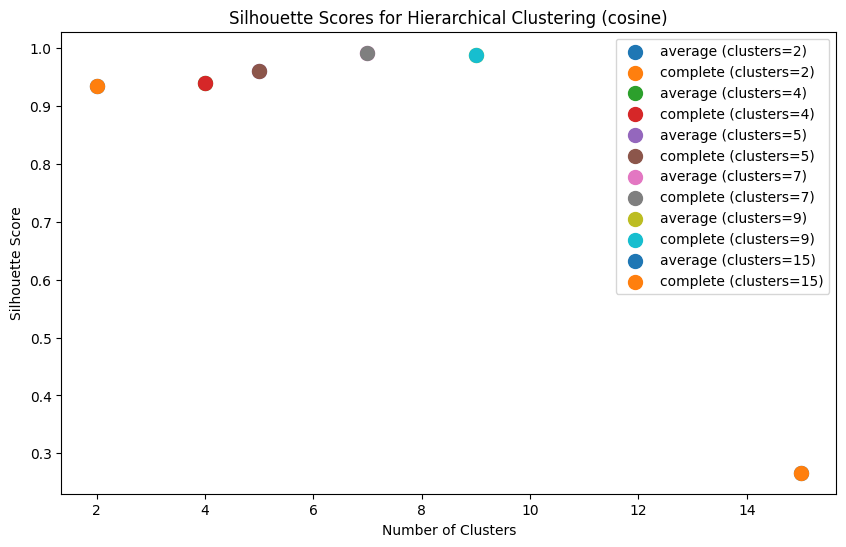

✅ Best Parameters: {'n_clusters': 7, 'linkage': 'average'}
✅ Best Silhouette Score: 0.9922, Best DBI: 0.1923
Best Parameters for Hierarchical Clustering: {'n_clusters': 7, 'linkage': 'average'}


In [20]:
BEST_OPTIMIZE_HIERARCHICAL, results_cosine = optimize_hierarchical_clustering(tag_embeddings, 
                                                              n_clusters_values=[2, 4, 5, 7 ,9, 15], 
                                                              metric="cosine")

# Output Best Parameters
print(f"Best Parameters for Hierarchical Clustering: {BEST_OPTIMIZE_HIERARCHICAL}")

🔄 Testing 2 clusters with ward linkage (metric=euclidean)...
🔄 Testing 2 clusters with average linkage (metric=euclidean)...
🔄 Testing 2 clusters with complete linkage (metric=euclidean)...
🔄 Testing 4 clusters with ward linkage (metric=euclidean)...
🔄 Testing 4 clusters with average linkage (metric=euclidean)...
🔄 Testing 4 clusters with complete linkage (metric=euclidean)...
🔄 Testing 5 clusters with ward linkage (metric=euclidean)...
🔄 Testing 5 clusters with average linkage (metric=euclidean)...
🔄 Testing 5 clusters with complete linkage (metric=euclidean)...
🔄 Testing 7 clusters with ward linkage (metric=euclidean)...
🔄 Testing 7 clusters with average linkage (metric=euclidean)...
🔄 Testing 7 clusters with complete linkage (metric=euclidean)...
🔄 Testing 9 clusters with ward linkage (metric=euclidean)...
🔄 Testing 9 clusters with average linkage (metric=euclidean)...
🔄 Testing 9 clusters with complete linkage (metric=euclidean)...
🔄 Testing 15 clusters with ward linkage (metric=eu

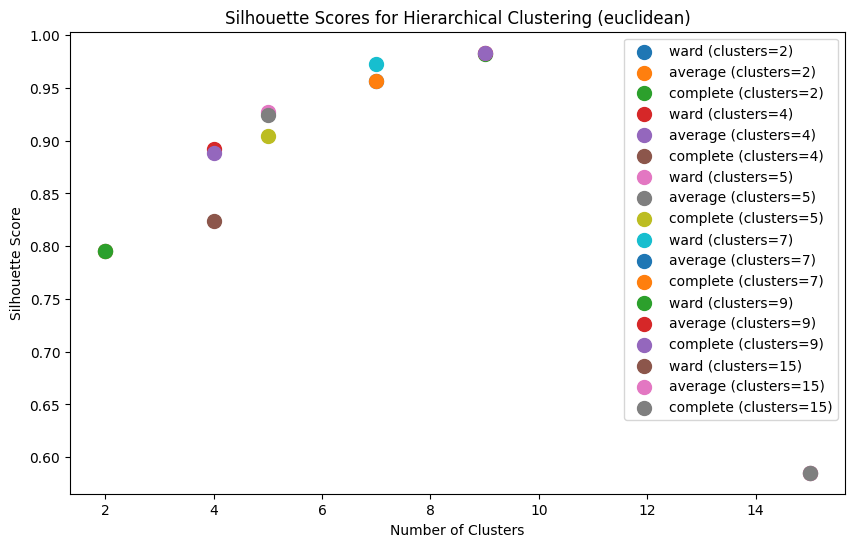

✅ Best Parameters: {'n_clusters': 9, 'linkage': 'average'}
✅ Best Silhouette Score: 0.9834, Best DBI: 0.1175
Best Parameters for Hierarchical Clustering: {'n_clusters': 9, 'linkage': 'average'}


In [22]:
BEST_OPTIMIZE_HIERARCHICAL, results_cosine = optimize_hierarchical_clustering(tag_embeddings, 
                                                              n_clusters_values=[2, 4, 5, 7 ,9, 15], 
                                                              metric="euclidean")

# Output Best Parameters
print(f"Best Parameters for Hierarchical Clustering: {BEST_OPTIMIZE_HIERARCHICAL}")

In [25]:
def apply_hierarchical_clustering(data, n_clusters=5, metric="cosine", linkage="average", visualize=True):
    """
    Applies Hierarchical Clustering (Agglomerative Clustering) and evaluates performance.
    
    Parameters:
    - data (numpy.ndarray): Feature matrix (word embeddings or numerical data).
    - n_clusters (int): Number of clusters to form.
    - metric (str): Distance metric to use ('euclidean' or 'cosine').
    - linkage (str): Linkage method ('ward', 'average', 'complete').
    - visualize (bool): If True, visualize the clusters using UMAP.
    
    Returns:
    - labels (numpy.ndarray): Cluster labels assigned to each data point.
    - silhouette_avg (float): Silhouette Score for cluster quality evaluation.
    - dbi_score (float): Davies-Bouldin Index (lower is better).
    """

    # Validate metric and linkage combination
    if metric == "cosine" and linkage == "ward":
        raise ValueError("❌ 'ward' linkage only supports Euclidean distance! Use 'average' or 'complete' for Cosine.")

    # Remove zero vectors (important for Cosine Distance)
    non_zero_mask = np.any(data != 0, axis=1)
    filtered_data = data[non_zero_mask]  # Remove zero vectors

    if len(filtered_data) == 0:
        raise ValueError("❌ All vectors are zero! Cannot cluster.")

    # Normalize for Cosine Distance (important)
    data_processed = normalize(filtered_data, axis=1) if metric == "cosine" else filtered_data

    # Apply Hierarchical Clustering
    clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage, metric=metric)
    labels = clusterer.fit_predict(data_processed)

    # Compute Evaluation Metrics
    if len(set(labels)) > 1:  # Ensure at least 2 clusters exist
        silhouette_avg = silhouette_score(data_processed, labels, metric=metric)
        dbi_score = davies_bouldin_score(data_processed, labels)
        print(f"✅ Silhouette Score: {silhouette_avg:.4f}")
        print(f"✅ Davies-Bouldin Index: {dbi_score:.4f}")
    else:
        print("⚠️ Clustering resulted in fewer than 2 clusters. Evaluation skipped.")
        silhouette_avg, dbi_score = -1, -1

    # Visualize Clusters (Optional)
    if visualize:
        print("📊 Visualizing Clusters using UMAP...")
        reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, n_components=2)
        reduced_embeddings = reducer.fit_transform(data_processed)

        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=reduced_embeddings[:, 0], y=reduced_embeddings[:, 1], hue=labels, palette="viridis", s=30)
        plt.title(f"Hierarchical Clustering Visualization ({n_clusters} Clusters)")
        plt.xlabel("UMAP Component 1")
        plt.ylabel("UMAP Component 2")
        plt.legend(title="Cluster")
        plt.show()

    return labels, silhouette_avg, dbi_score


✅ Silhouette Score: 0.9886
✅ Davies-Bouldin Index: 0.0000
📊 Visualizing Clusters using UMAP...


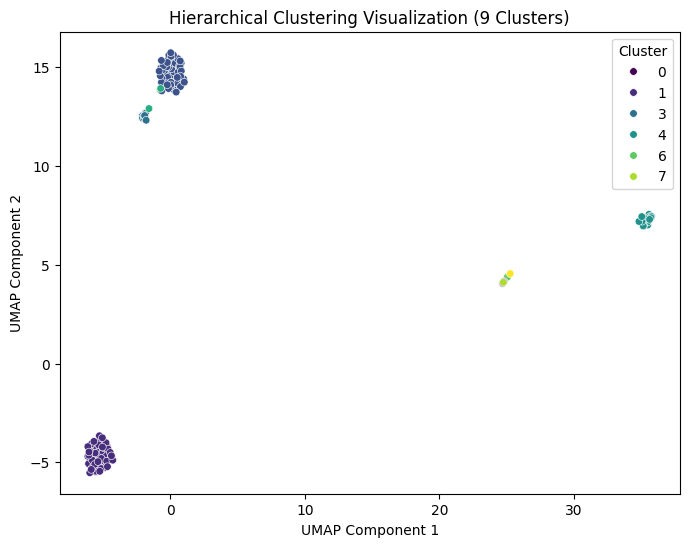

In [47]:
labels, silhouette_avg, dbi_score = apply_hierarchical_clustering(tag_embeddings, 
                                                                  n_clusters=BEST_OPTIMIZE_HIERARCHICAL["n_clusters"], 
                                                                  metric="cosine", 
                                                                  linkage=BEST_OPTIMIZE_HIERARCHICAL["linkage"], 
                                                                  visualize=True)

In [48]:
sentences = pd.read_parquet("input/tag_sentences.parquet").squeeze()
sentences

0               [history, museum, specialty, museum]
1                                        [bar, club]
2                                [sacred, religious]
3                                       [boat, tour]
4                                      [body, water]
                            ...                     
1761                                         [beach]
1762                                        [bridge]
1763    [sacred, religious, architectural, building]
1764                                         [beach]
1765                                       [lookout]
Name: cleaned_tags, Length: 1766, dtype: object

In [49]:
labels

array([0, 2, 2, 4, 2, 4, 0, 4, 4, 2, 6, 4, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2,
       2, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 0, 2, 4, 2, 1, 1, 4, 1, 1,
       2, 6, 1, 2, 1, 1, 2, 2, 3, 1, 5, 2, 2, 2, 1, 2, 2, 0, 4, 2, 1, 1,
       1, 1, 1, 1, 2, 1, 2, 1, 4, 3, 2, 1, 1, 1, 2, 2, 2, 1, 3, 1, 0, 1,
       3, 2, 2, 3, 2, 2, 4, 2, 2, 1, 2, 4, 2, 1, 4, 2, 2, 2, 2, 2, 1, 1,
       4, 3, 1, 2, 2, 2, 1, 2, 5, 1, 1, 4, 2, 4, 1, 1, 1, 1, 1, 2, 1, 2,
       1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 4, 2, 2, 1, 1, 1, 2, 2, 7, 2, 2, 2,
       3, 2, 2, 4, 1, 1, 2, 3, 4, 1, 2, 8, 5, 4, 2, 2, 4, 1, 1, 2, 2, 3])

In [50]:
clusters = {}
for i, label in enumerate(labels):
    if label != -1:  # Ignore noise points
        clusters.setdefault(label, []).append(list(sentences.iloc[i]))  # Convert NumPy array to Python list


In [51]:
clusters

{0: [['history', 'museum', 'specialty', 'museum'],
  ['garden'],
  [],
  ['beach'],
  ['beach']],
 2: [['bar', 'club'],
  ['sacred', 'religious'],
  ['body', 'water'],
  ['hot', 'spring', 'geyser'],
  ['shopping', 'mall'],
  ['historic'],
  ['sacred', 'religious'],
  ['monument', 'statue'],
  ['specialty', 'museum'],
  ['sacred', 'religious'],
  ['sacred', 'religious'],
  ['nature', 'wildlife', 'area'],
  ['zoo'],
  ['waterfall'],
  ['natural', 'history', 'museum'],
  ['cavern', 'cave', 'nature', 'wildlife', 'area'],
  [],
  ['scuba', 'snorkeling', 'adrenaline', 'extreme', 'tour'],
  [],
  ['shopping', 'mall'],
  ['national', 'park'],
  [],
  ['theme', 'park', 'water', 'park'],
  [],
  ['waterfall'],
  ['flea', 'street', 'market'],
  ['neighborhood'],
  ['history', 'museum', 'specialty', 'museum'],
  ['art', 'gallery'],
  ['cavern', 'cave', 'geologic', 'formation'],
  ['beach'],
  [],
  ['geologic', 'formation'],
  ['sightseeing', 'tour'],
  ['observation', 'deck', 'tower', 'lookout'],

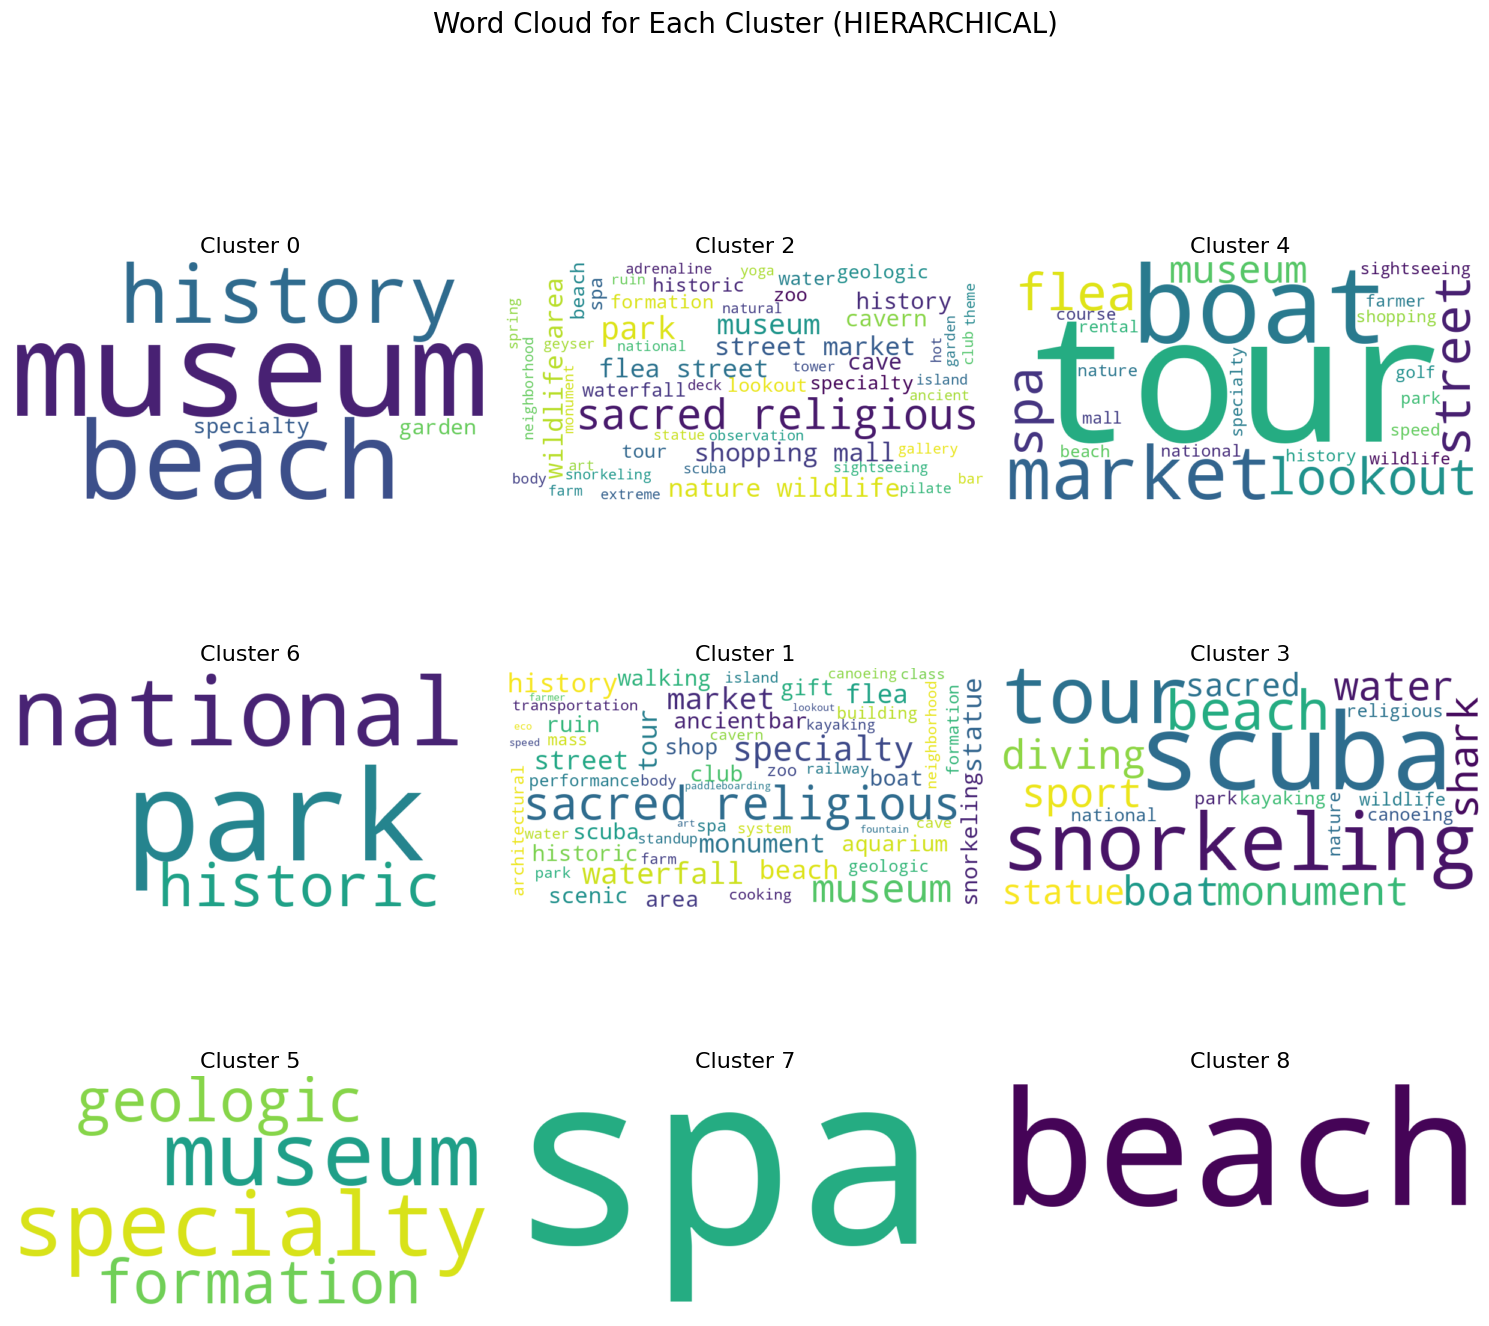

In [53]:
def flatten_list(nested_list):
    return [item for sublist in nested_list for item in (sublist if isinstance(sublist, list) else [sublist])]

data_clusters = {cluster_id: flatten_list(words) for cluster_id, words in clusters.items()}

# Plot Word Clouds
num_clusters = len(data_clusters)
columns = 3
rows = (num_clusters + columns - 1) // columns

fig, axes = plt.subplots(rows, columns, figsize=(15, 5 * rows))
fig.suptitle("Word Cloud for Each Cluster (HIERARCHICAL)", fontsize=20)

axes = axes.flatten()

for idx, (cluster_id, words) in enumerate(data_clusters.items()):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words))
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f"Cluster {cluster_id}", fontsize=16)
    axes[idx].axis('off')

# Hide any unused subplots
for i in range(len(data_clusters), len(axes)):
    axes[i].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()